# Full-Batch LLM Comparison

This notebook compares the two full LLM batches used in the thesis:

- `few-shot`, temperature `0.5`
- `zero-shot`, temperature `0.0`

Each condition is compared separately against the human `Advanced` and human `Elementary` benchmarks. The notebook is organized so that each batch can be discussed on its own before the two are compared directly.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
OUTPUTS = ROOT / 'outputs'
FIG_DIR = OUTPUTS / 'full_batch_figures'
TABLE_DIR = OUTPUTS / 'full_batch_tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
human_text = pd.read_csv(OUTPUTS / 'human_baseline_text_metrics.csv')
human_pairwise = pd.read_csv(OUTPUTS / 'human_baseline_pairwise_comparisons.csv')
few_text = pd.read_csv(OUTPUTS / 'full_batch_fewshot05_text_metrics.csv')
few_pairwise = pd.read_csv(OUTPUTS / 'full_batch_fewshot05_pairwise.csv')
zero_text = pd.read_csv(OUTPUTS / 'full_batch_zeroshot00_text_metrics.csv')
zero_pairwise = pd.read_csv(OUTPUTS / 'full_batch_zeroshot00_pairwise.csv')

CORE_METRICS = ['aoa', 'concreteness', 'imageability', 'cli', 'tier2_proxy_token_ratio', 'fk_grade', 'mtld', 'lexical_coverage']
DELTA_METRICS = ['delta_aoa', 'delta_concreteness', 'delta_imageability', 'delta_cli', 'delta_tier2_proxy_token_ratio', 'delta_fk_grade', 'delta_mtld', 'semantic_similarity_sbert']
METRIC_LABELS = {
    'aoa': 'AoA',
    'concreteness': 'Concreteness',
    'imageability': 'Imageability',
    'cli': 'CLI',
    'tier2_proxy_token_ratio': 'Tier 2 proxy',
    'fk_grade': 'FKGL',
    'mtld': 'MTLD',
    'lexical_coverage': 'MRC coverage',
    'delta_aoa': '? AoA',
    'delta_concreteness': '? Concreteness',
    'delta_imageability': '? Imageability',
    'delta_cli': '? CLI',
    'delta_tier2_proxy_token_ratio': '? Tier 2 proxy',
    'delta_fk_grade': '? FKGL',
    'delta_mtld': '? MTLD',
    'semantic_similarity_sbert': 'SBERT similarity',
}

human_means = human_text.groupby('level')[CORE_METRICS].mean().round(2)
human_means


,aoa,concreteness,imageability,cli,tier2_proxy_token_ratio,fk_grade,mtld,lexical_coverage
level,,,,,,,,
Advanced,359.45,355.63,383.01,-0.12,0.10,11.13,110.29,0.51
Elementary,340.94,355.62,383.27,0.19,0.07,8.16,83.93,0.56
Intermediate,355.03,354.85,382.18,-0.07,0.09,9.84,99.84,0.53


## Helper Functions

The helper functions below build comparable tables for each condition. Two kinds of comparison are used throughout the notebook:

- **Level means**: compare the average metric values of the LLM outputs to the human `Advanced` and human `Elementary` texts.
- **Pairwise deltas**: compare the LLM simplifications to their original `Advanced` source texts in the same way the human `Elementary` texts are compared to `Advanced`.

In [3]:
def level_summary(text_df: pd.DataFrame, llm_variant: str, llm_label: str) -> pd.DataFrame:
    subset = text_df[text_df['level'].isin(['Advanced', 'Elementary'])].copy()
    human = subset[subset['source_type'] == 'human_reference'].copy()
    llm = subset[subset['variant'] == llm_variant].copy()
    human = human.assign(display_label=human['level'].map({'Advanced': 'Human Advanced', 'Elementary': 'Human Elementary'}))
    llm = llm.assign(display_label=llm_label)
    combined = pd.concat([human, llm], ignore_index=True)
    summary = combined.groupby('display_label')[CORE_METRICS].mean().round(2)
    return summary.reindex(['Human Advanced', 'Human Elementary', llm_label])

def pairwise_summary(pairwise_df: pd.DataFrame, llm_variant: str, llm_label: str) -> pd.DataFrame:
    subset = pairwise_df[pairwise_df['comparison_type'].isin(['human_reference', 'llm_simplification'])].copy()
    subset['display_label'] = subset.apply(
        lambda row: 'Human Elementary vs Advanced' if row['comparison_type'] == 'human_reference' else llm_label,
        axis=1,
    )
    subset = subset[(subset['comparison_type'] == 'human_reference') | (subset['variant'] == llm_variant)]
    summary = subset.groupby('display_label')[DELTA_METRICS].mean().round(2)
    return summary.reindex(['Human Elementary vs Advanced', llm_label])

def elementary_distance(level_df: pd.DataFrame, llm_label: str) -> pd.DataFrame:
    advanced = level_df.loc['Human Advanced']
    elementary = level_df.loc['Human Elementary']
    llm = level_df.loc[llm_label]
    rows = []
    for metric in CORE_METRICS[:-1]:
        rows.append({
            'metric': METRIC_LABELS[metric],
            'distance_to_advanced': round(abs(llm[metric] - advanced[metric]), 2),
            'distance_to_elementary': round(abs(llm[metric] - elementary[metric]), 2),
        })
    return pd.DataFrame(rows)

def save_table(df: pd.DataFrame, name: str) -> None:
    if isinstance(df.index, pd.RangeIndex):
        df.to_csv(TABLE_DIR / name, index=False)
    else:
        df.to_csv(TABLE_DIR / name)

def plot_metric_bars(level_df: pd.DataFrame, title: str, filename: str) -> None:
    plot_df = level_df.reset_index(names='label').melt(id_vars='label', var_name='metric', value_name='value')
    plot_df['metric_label'] = plot_df['metric'].map(METRIC_LABELS)
    plt.figure(figsize=(16, 8))
    sns.barplot(data=plot_df, x='metric_label', y='value', hue='label')
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()

def plot_pairwise_bars(pair_df: pd.DataFrame, title: str, filename: str) -> None:
    plot_df = pair_df.reset_index(names='label').melt(id_vars='label', var_name='metric', value_name='value')
    plot_df['metric_label'] = plot_df['metric'].map(METRIC_LABELS)
    plt.figure(figsize=(16, 8))
    sns.barplot(data=plot_df, x='metric_label', y='value', hue='label')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()


## Human Benchmark

The tables below are the anchor for all later comparisons. `Human Advanced` represents the original source texts, while `Human Elementary` represents the target simplification level produced by human editors in the corpus.

In [4]:
display(human_means)
save_table(human_means, 'human_level_means.csv')

human_delta_summary = human_pairwise.groupby('comparison_type')[DELTA_METRICS].mean().round(2)
display(human_delta_summary)
save_table(human_delta_summary, 'human_pairwise_summary.csv')


,aoa,concreteness,imageability,cli,tier2_proxy_token_ratio,fk_grade,mtld,lexical_coverage
level,,,,,,,,
Advanced,359.45,355.63,383.01,-0.12,0.10,11.13,110.29,0.51
Elementary,340.94,355.62,383.27,0.19,0.07,8.16,83.93,0.56
Intermediate,355.03,354.85,382.18,-0.07,0.09,9.84,99.84,0.53


,delta_aoa,delta_concreteness,delta_imageability,delta_cli,delta_tier2_proxy_token_ratio,delta_fk_grade,delta_mtld,semantic_similarity_sbert
comparison_type,,,,,,,,
human_reference,-18.51,-0.01,0.26,0.3,-0.03,-2.98,-26.36,0.89


## Few-Shot 0.5

This section asks two questions:

1. Is the `few-shot 0.5` output profile closer to `Human Advanced` or `Human Elementary`?
2. When compared to the original Advanced source texts, does its average shift resemble the human Elementary shift?

In [5]:
few_variant = 'openai::openai/gpt-5.2::few_shot::temp=0.5'
few_label = 'LLM Few-shot 0.5'
few_level = level_summary(few_text, few_variant, few_label)
few_pair = pairwise_summary(few_pairwise, few_variant, few_label)
few_distance = elementary_distance(few_level, few_label)

display(few_level)
display(few_pair)
display(few_distance)

save_table(few_level, 'fewshot05_level_summary.csv')
save_table(few_pair, 'fewshot05_pairwise_summary.csv')
few_distance.to_csv(TABLE_DIR / 'fewshot05_distance_table.csv', index=False)


,aoa,concreteness,imageability,cli,tier2_proxy_token_ratio,fk_grade,mtld,lexical_coverage
display_label,,,,,,,,
Human Advanced,359.45,355.63,383.01,-0.17,0.10,11.13,110.29,0.51
Human Elementary,340.94,355.62,383.27,0.14,0.07,8.16,83.93,0.56
LLM Few-shot 0.5,340.18,355.48,383.39,0.15,0.07,7.15,94.82,0.56


,delta_aoa,delta_concreteness,delta_imageability,delta_cli,delta_tier2_proxy_token_ratio,delta_fk_grade,delta_mtld,semantic_similarity_sbert
display_label,,,,,,,,
Human Elementary vs Advanced,-18.51,-0.01,0.26,0.30,-0.03,-2.98,-26.36,0.89
LLM Few-shot 0.5,-19.27,-0.15,0.39,0.32,-0.03,-3.98,-15.46,0.90


,metric,distance_to_advanced,distance_to_elementary
0,AoA,19.27,0.76
1,Concreteness,0.15,0.14
2,Imageability,0.38,0.12
3,CLI,0.32,0.01
4,Tier 2 proxy,0.03,0.00
5,FKGL,3.98,1.01
6,MTLD,15.47,10.89


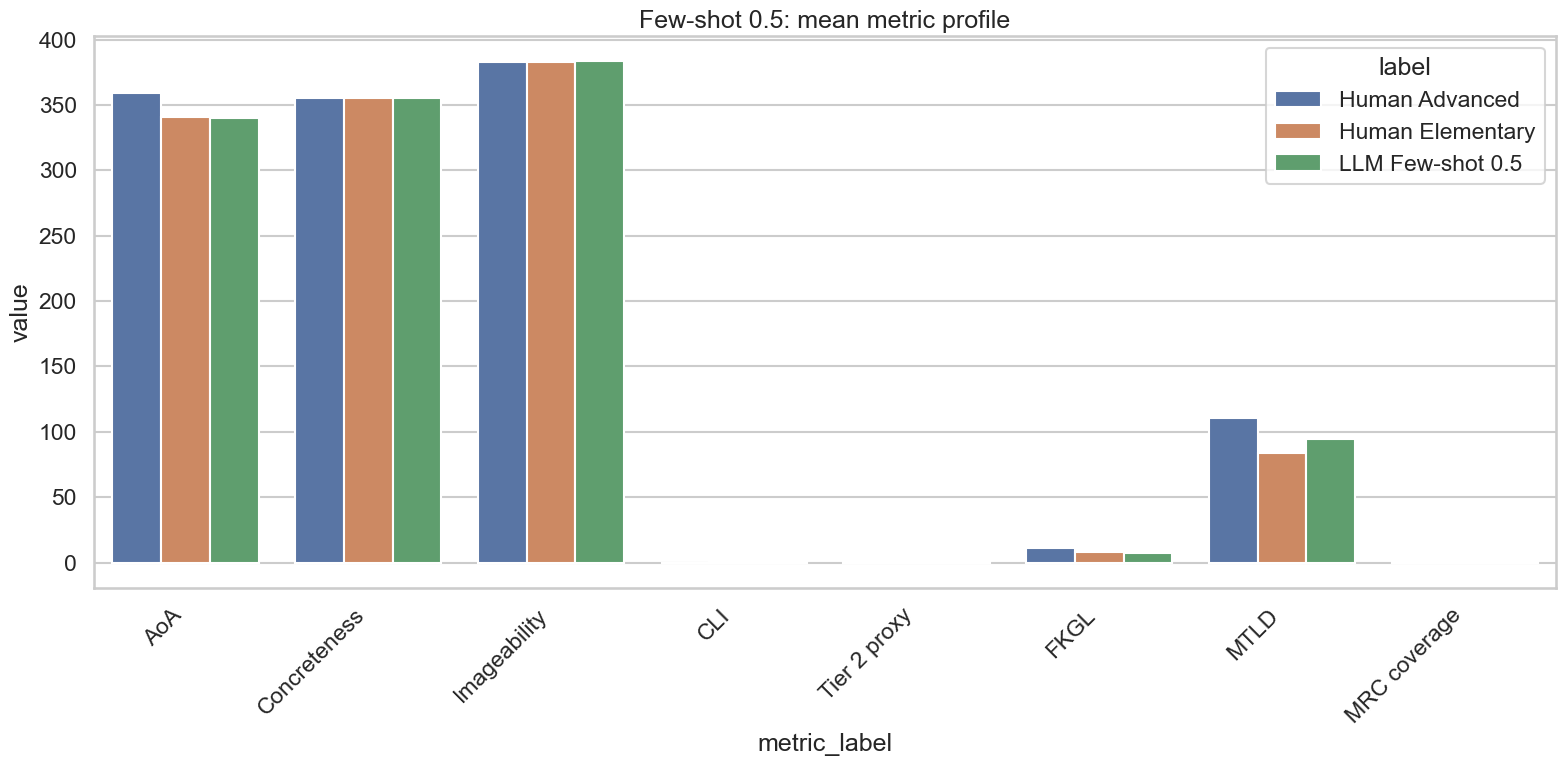

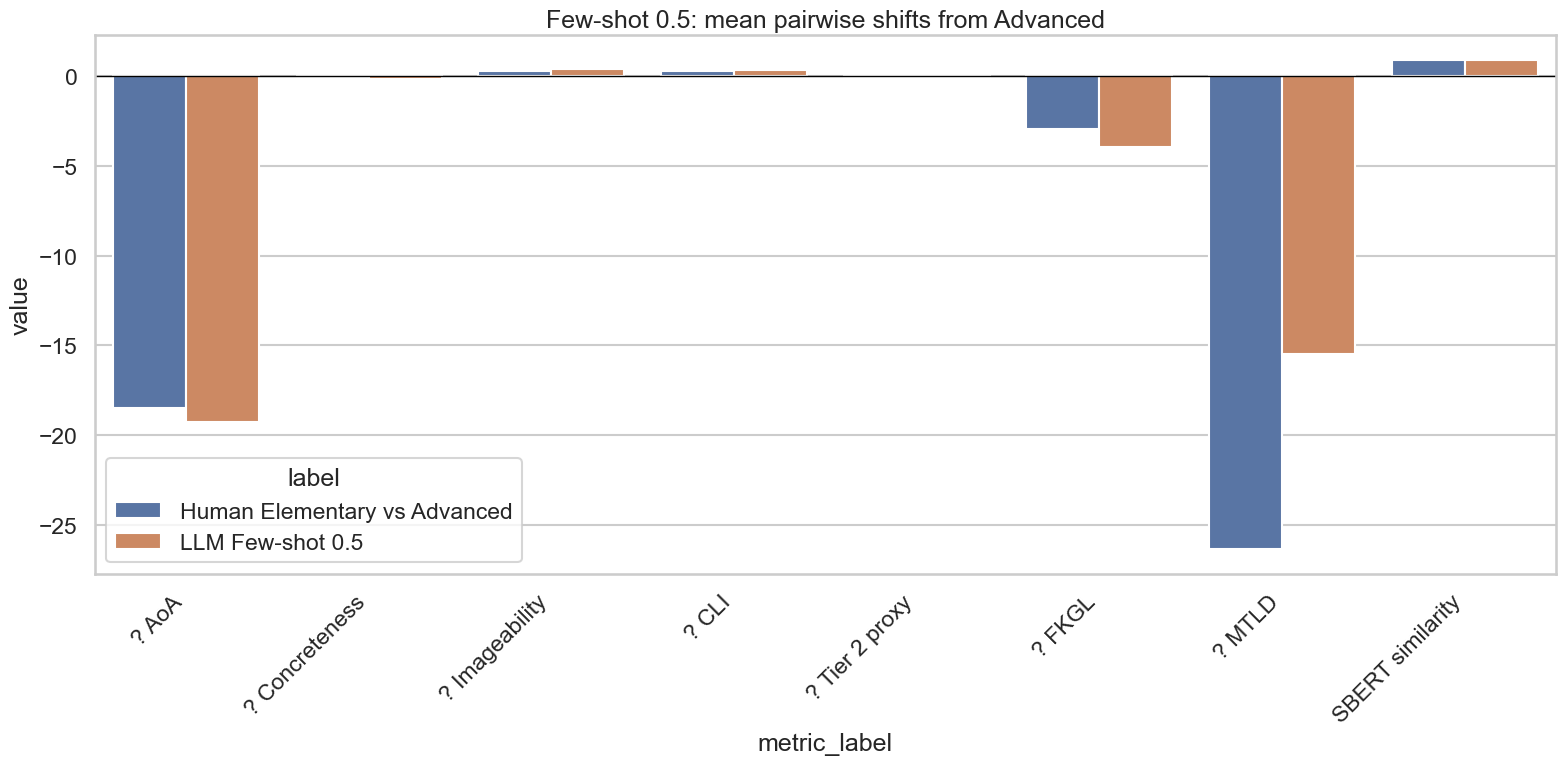

In [6]:
plot_metric_bars(few_level, 'Few-shot 0.5: mean metric profile', 'fewshot05_profile.png')
plot_pairwise_bars(few_pair, 'Few-shot 0.5: mean pairwise shifts from Advanced', 'fewshot05_pairwise.png')


## Zero-Shot 0.0

This section mirrors the few-shot analysis, but for the conservative zero-shot baseline.

In [7]:
zero_variant = 'openai::openai/gpt-5.2::zero_shot::temp=0.0'
zero_label = 'LLM Zero-shot 0.0'
zero_level = level_summary(zero_text, zero_variant, zero_label)
zero_pair = pairwise_summary(zero_pairwise, zero_variant, zero_label)
zero_distance = elementary_distance(zero_level, zero_label)

display(zero_level)
display(zero_pair)
display(zero_distance)

save_table(zero_level, 'zeroshot00_level_summary.csv')
save_table(zero_pair, 'zeroshot00_pairwise_summary.csv')
zero_distance.to_csv(TABLE_DIR / 'zeroshot00_distance_table.csv', index=False)


,aoa,concreteness,imageability,cli,tier2_proxy_token_ratio,fk_grade,mtld,lexical_coverage
display_label,,,,,,,,
Human Advanced,359.45,355.63,383.01,-0.17,0.10,11.13,110.29,0.51
Human Elementary,340.94,355.62,383.27,0.13,0.07,8.16,83.93,0.56
LLM Zero-shot 0.0,338.20,355.27,383.24,0.17,0.07,7.16,96.81,0.57


,delta_aoa,delta_concreteness,delta_imageability,delta_cli,delta_tier2_proxy_token_ratio,delta_fk_grade,delta_mtld,semantic_similarity_sbert
display_label,,,,,,,,
Human Elementary vs Advanced,-18.51,-0.01,0.26,0.30,-0.03,-2.98,-26.36,0.89
LLM Zero-shot 0.0,-21.25,-0.36,0.24,0.34,-0.03,-3.97,-13.48,0.90


,metric,distance_to_advanced,distance_to_elementary
0,AoA,21.25,2.74
1,Concreteness,0.36,0.35
2,Imageability,0.23,0.03
3,CLI,0.34,0.04
4,Tier 2 proxy,0.03,0.00
5,FKGL,3.97,1.00
6,MTLD,13.48,12.88


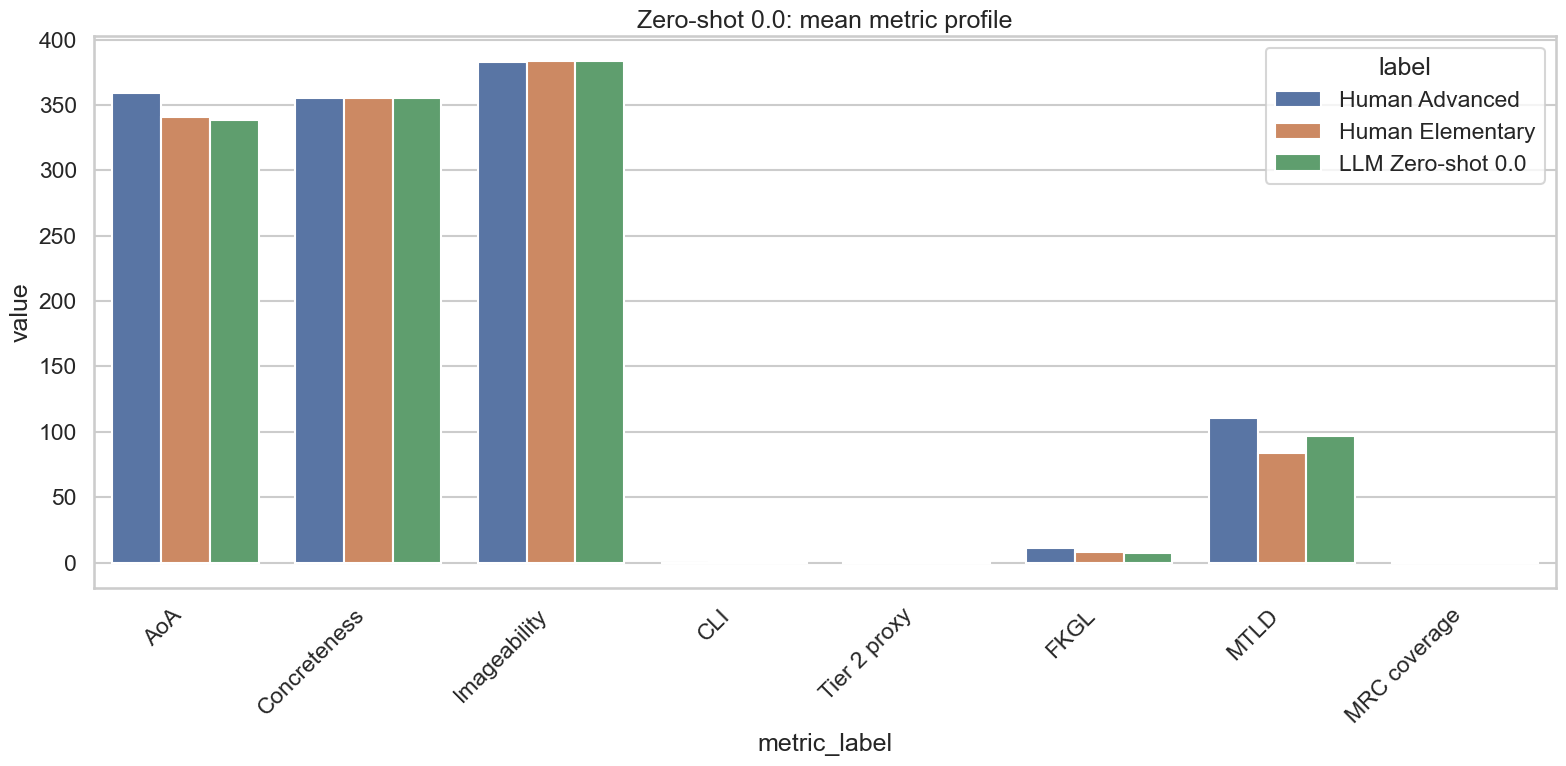

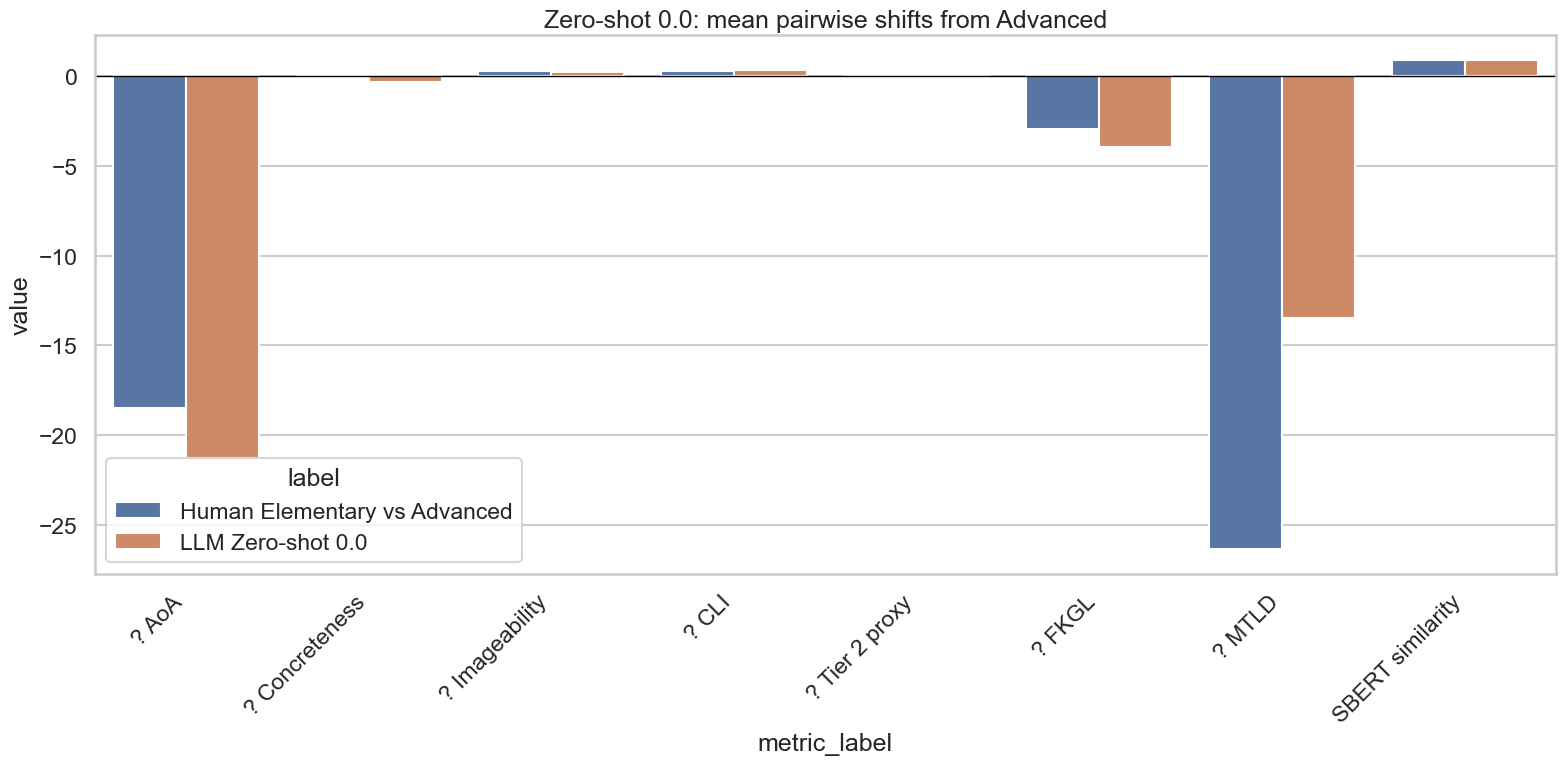

In [8]:
plot_metric_bars(zero_level, 'Zero-shot 0.0: mean metric profile', 'zeroshot00_profile.png')
plot_pairwise_bars(zero_pair, 'Zero-shot 0.0: mean pairwise shifts from Advanced', 'zeroshot00_pairwise.png')


## Direct LLM-to-LLM Comparison

Now that both conditions have been compared separately to the human benchmark, the final step is to compare them directly. The first table compares mean text profiles. The second compares their average shifts away from `Human Advanced`.

In [9]:
llm_direct = pd.concat([few_level.loc[[few_label]], zero_level.loc[[zero_label]]])
display(llm_direct)
save_table(llm_direct, 'llm_direct_profile_comparison.csv')

llm_pair_direct = pd.concat([few_pair.loc[[few_label]], zero_pair.loc[[zero_label]]])
display(llm_pair_direct)
save_table(llm_pair_direct, 'llm_direct_pairwise_comparison.csv')


,aoa,concreteness,imageability,cli,tier2_proxy_token_ratio,fk_grade,mtld,lexical_coverage
display_label,,,,,,,,
LLM Few-shot 0.5,340.18,355.48,383.39,0.15,0.07,7.15,94.82,0.56
LLM Zero-shot 0.0,338.20,355.27,383.24,0.17,0.07,7.16,96.81,0.57


,delta_aoa,delta_concreteness,delta_imageability,delta_cli,delta_tier2_proxy_token_ratio,delta_fk_grade,delta_mtld,semantic_similarity_sbert
display_label,,,,,,,,
LLM Few-shot 0.5,-19.27,-0.15,0.39,0.32,-0.03,-3.98,-15.46,0.9
LLM Zero-shot 0.0,-21.25,-0.36,0.24,0.34,-0.03,-3.97,-13.48,0.9


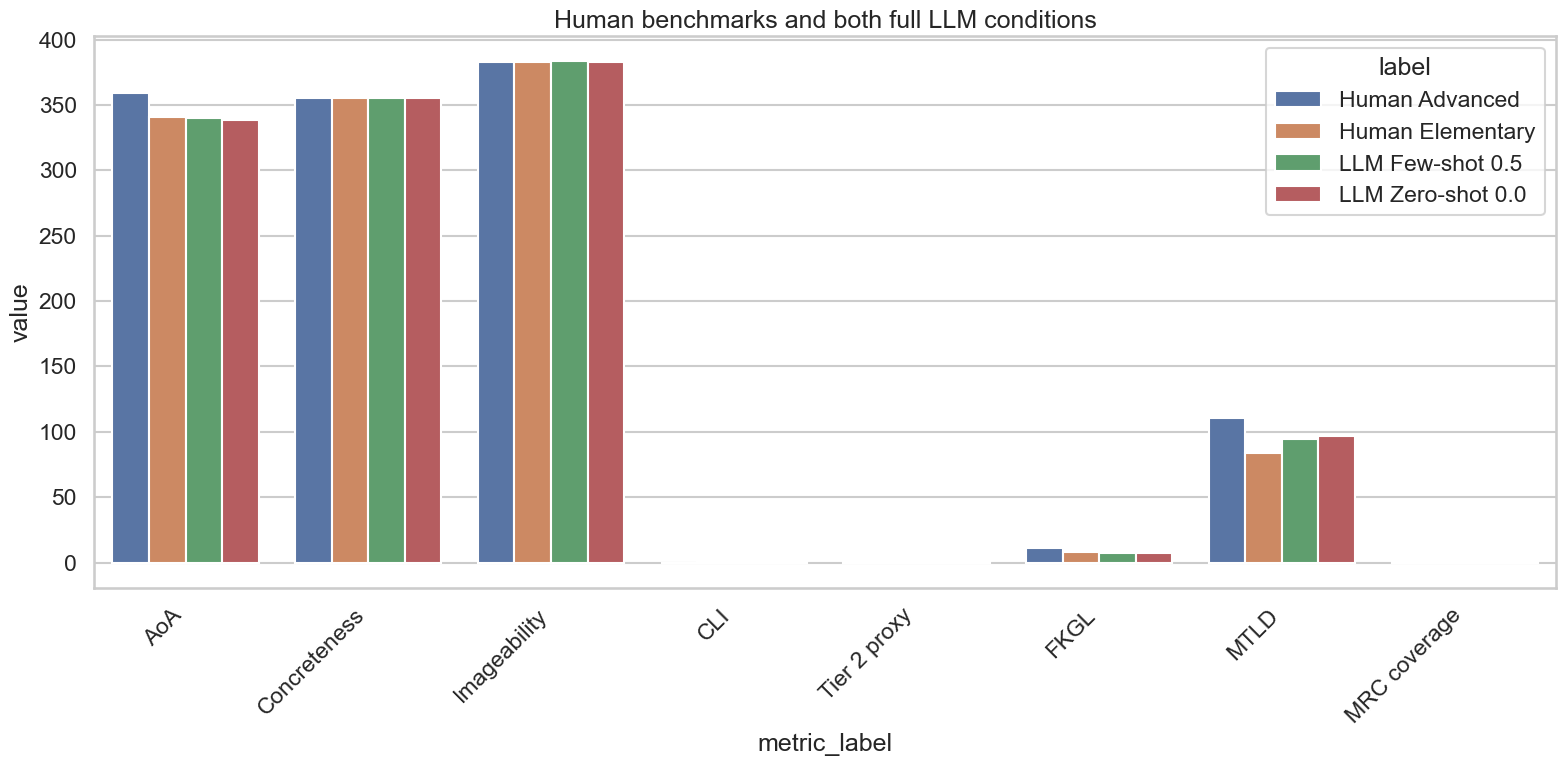

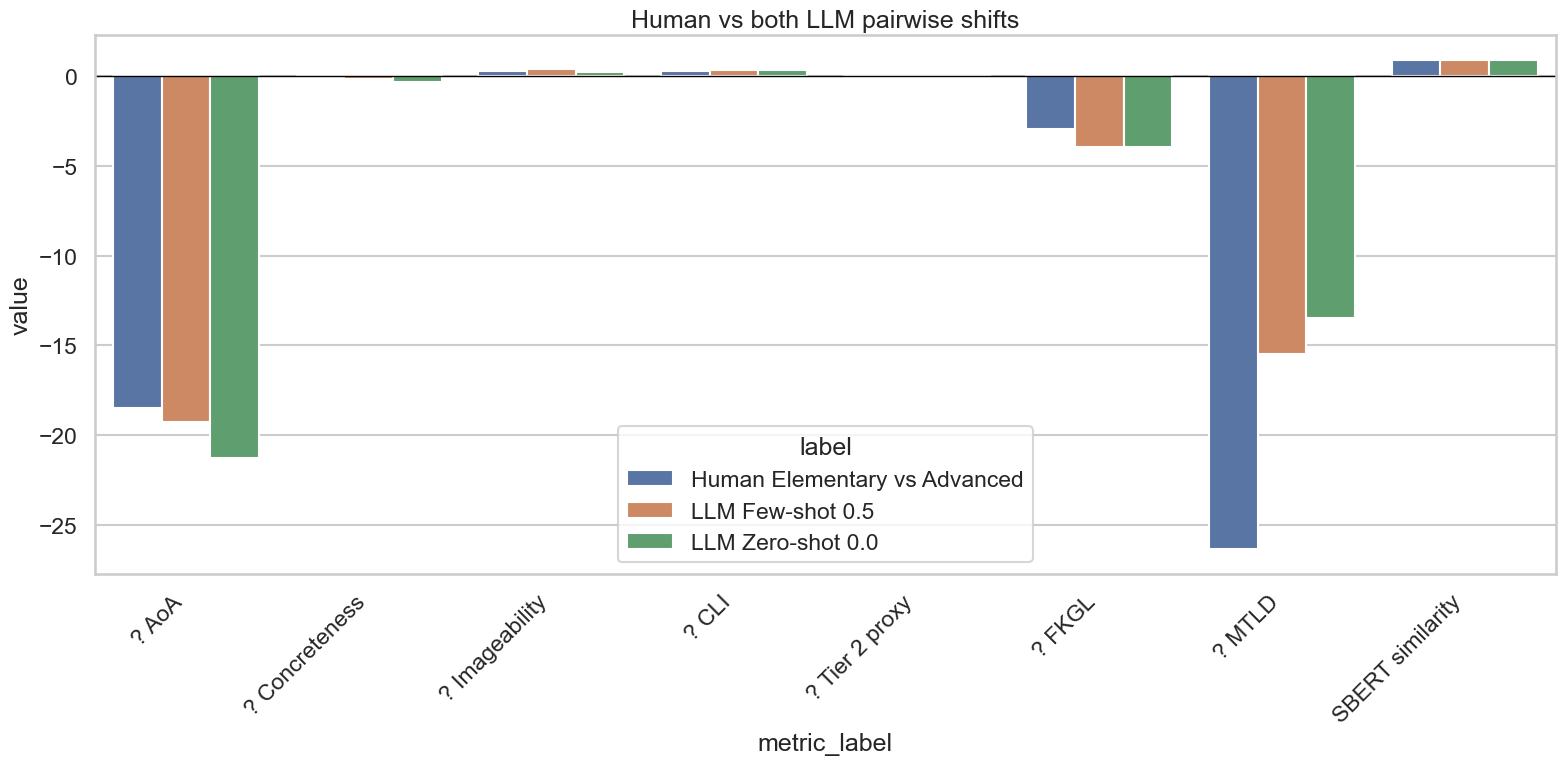

In [10]:
plot_metric_bars(pd.concat([few_level.loc[['Human Advanced', 'Human Elementary', few_label]], zero_level.loc[[zero_label]]]), 'Human benchmarks and both full LLM conditions', 'full_batch_combined_profile.png')
plot_pairwise_bars(pd.concat([few_pair.loc[['Human Elementary vs Advanced', few_label]], zero_pair.loc[[zero_label]]]), 'Human vs both LLM pairwise shifts', 'full_batch_combined_pairwise.png')


## Notes for Thesis Use

The exported CSVs in `outputs/full_batch_tables` and figures in `outputs/full_batch_figures` are meant for thesis drafting. The most useful tables for the main text are usually:

- the two per-condition level summaries
- the two per-condition pairwise summaries
- the direct LLM-to-LLM pairwise comparison

The distance tables are especially useful for discussing whether an LLM condition remains closer to the original `Advanced` profile or moves toward the human `Elementary` profile.